In [1]:
import numpy as np
import cortex
import torch
from voxelwise_utils import *

/home/jlg/jenh/voxelwise_tutorials_data/shortclips


In [2]:
backend = set_default_backend()
print(f"Backend set to: {backend.name}")

Backend set to: torch_cuda


In [32]:
# Load standard features
FEATURES_DIR = "/home/jlg/shiochiba/Data/data-for-shio"
features = np.load(os.path.join(FEATURES_DIR, 'visual_segmented-objects.npz'))

train_keys_std = [k for k in features.keys() if k.startswith('train')]

X_train_std = np.concatenate([features[k][5:] for k in train_keys_std], axis = 0).astype('float32')

X_test_std = features['test2'][5:].astype('float32')

print("X_train_std shape:", X_train_std.shape)
print("X_test_std shape:", X_test_std.shape)

X_train_std shape: (1471, 578)
X_test_std shape: (86, 578)


In [33]:
# Feature z-scoring
X_train_std, X_test_std = zscore_features(X_train_std, X_test_std)

In [34]:
# Load KLR BOLD
BOLD_DIR = "/home/jlg/shiochiba/Data/data-for-shio"

Y_train_KLR_npz = np.load(os.path.join(BOLD_DIR, "KLR_train_bold.npz"))
Y_train_KLR = Y_train_KLR_npz['bold'].astype('float32')

Y_test_npz = np.load(os.path.join(BOLD_DIR, "KLR_test_bold.npz"))
Y_test_KLR = Y_test_npz['bold'].astype('float32')

print(f"Y_train shape:{Y_train_KLR.shape}")
print(f"Y_test shape:{Y_test_KLR.shape}")

Y_train shape:(1471, 97658)
Y_test shape:(6, 86, 97658)


In [35]:
runlens_KLR = Y_train_KLR_npz['runlens']
run_onsets_KLR = compute_run_onsets(runlens_KLR)

In [36]:
# Z-score each run idependently
Y_train_KLR = zscore_runs(Y_train_KLR, run_onsets_KLR)
Y_train_KLR = np.nan_to_num(Y_train_KLR)

In [37]:
# Average test repeats then z-score across voxels
Y_test_KLR = Y_test_KLR.mean(axis=0)
Y_test_KLR = (Y_test_KLR - np.mean(Y_test_KLR, axis=0)) / (np.std(Y_test_KLR, axis=0) + 1e-12)
Y_test_KLR = np.nan_to_num(Y_test_KLR)

print("Z-scored Y_train shape:", Y_train_KLR.shape)
print("Z-scored Y_test_std_KLR shape:", Y_test_KLR.shape)

Z-scored Y_train shape: (1471, 97658)
Z-scored Y_test_std_KLR shape: (86, 97658)


In [38]:
n_samples_train_std = X_train_std.shape[0]
cv_std = generate_leave_one_run_out(n_samples_train_std, run_onsets_KLR)
cv_std = check_cv(cv_std)

In [55]:
# Fit standard KLR model
pipeline_std_KLR, scores_std_KLR = fit_kernel_ridge(
    X_train_std, X_test_std, Y_train_KLR, Y_test_KLR,
    cv = cv_std,
    delays=[1, 2, 3, 4],
    n_targets_batch=500,
    n_alphas_batch=10,
    n_targets_batch_refit=100, 
)

print("Scores shape:", scores_std_KLR.shape)

Scores shape: torch.Size([97658])


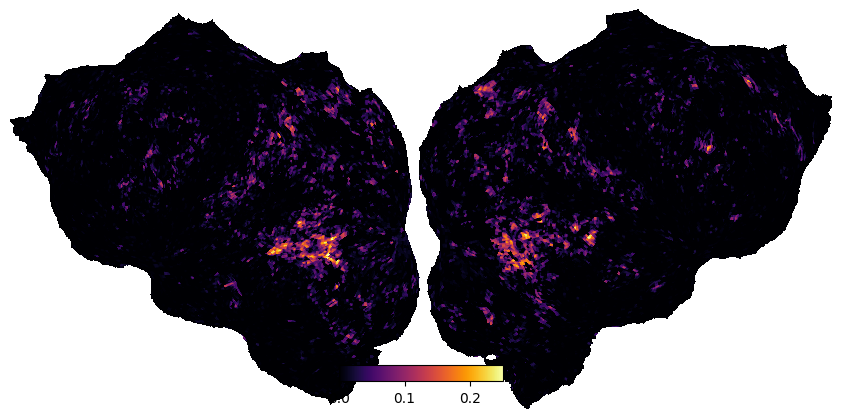

In [56]:
scores_std_KLR = clean_scores(scores_std_KLR)

subject ="KLR"

v = cortex.Volume(scores_std_KLR, "KLRfs", "report-attn", cmap='inferno', vmin=0, vmax=.25)
cortex.quickshow(v, height=400)
plt.show()

In [57]:
# Fitting model with standard features for ZXI
Y_train_ZXI_npz = np.load(os.path.join(BOLD_DIR, "ZXI_train_bold.npz"))
Y_train_ZXI = Y_train_ZXI_npz['bold'].astype('float32')

Y_test_ZXI_npz = np.load(os.path.join(BOLD_DIR, "ZXI_test_bold.npz"))
Y_test_ZXI = Y_test_ZXI_npz['bold'].astype('float32')

runlens_ZXI = Y_train_ZXI_npz['runlens']
run_onsets_ZXI = compute_run_onsets(runlens_ZXI)

# Z-score each run idependently
Y_train_ZXI = zscore_runs(Y_train_ZXI, run_onsets_ZXI)
Y_train_ZXI = np.nan_to_num(Y_train_ZXI)

# Average test repeats then z-score across voxels
Y_test_ZXI = Y_test_ZXI.mean(axis=0)
Y_test_ZXI = (Y_test_ZXI - np.mean(Y_test_ZXI, axis=0)) / (np.std(Y_test_ZXI, axis=0) + 1e-12)
Y_test_ZXI = np.nan_to_num(Y_test_ZXI)

pipeline_std_ZXI, scores_std_ZXI = fit_kernel_ridge(
    X_train_std, X_test_std, Y_train_ZXI, Y_test_ZXI,
    cv = cv_std,
    delays=[1, 2, 3, 4],
    n_targets_batch=500,
    n_alphas_batch=10,
    n_targets_batch_refit=100, 
)

print("Scores shape:", scores_std_ZXI.shape)

Scores shape: torch.Size([92811])


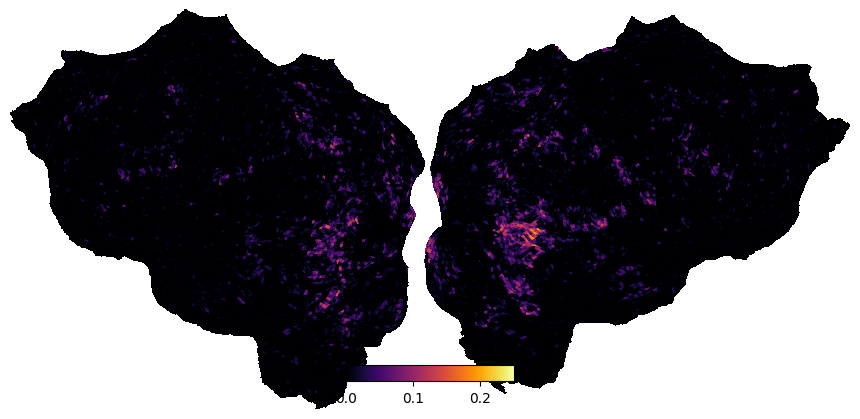

In [58]:
scores_std_ZXI = clean_scores(scores_std_ZXI)

subject ="ZXI"

v = cortex.Volume(scores_std_ZXI, "ZXIfs", "report-attn", cmap='inferno', vmin=0, vmax=.25)
cortex.quickshow(v, height=400)
plt.show()

In [59]:
# Loading gaze-corrected features for KLR
GAZE_FEATURES_DIR = "/home/jlg/shiochiba/gaze-corrected-semantics/data/features"
feature_name = 'visual_KLR-gaze-corrected-semantics.npz'
features = np.load(os.path.join(GAZE_FEATURES_DIR, feature_name))

if 'gaze' in feature_name:
    realfeatures_KLR = {}
    for movie, feature in features.items():
        if 'match' in movie:
            newname = movie.replace('match', '')
            print(newname)
            realfeatures_KLR[newname] = feature

    train_keys_gaze_KLR = [k for k in realfeatures_KLR.keys() if k.startswith('train')]

    X_train_gaze_KLR = np.concatenate([realfeatures_KLR[k][5:] for k in train_keys_gaze_KLR], axis=0).astype('float32')

    X_test_gaze_KLR  = realfeatures_KLR['test2'][5:].astype('float32')

else:
    train_keys_gaze_KLR = [k for k in features.files if k.startswith('train')]

    X_train_gaze_KLR = np.concatenate([features[k][5:] for k in train_keys_gaze_KLR], axis=0).astype('float32')

    X_test_gaze_KLR = features['test2'][5:].astype('float32')

print("X_train_gaze_KLR shape:", X_train_gaze_KLR.shape)
print("X_test_gaze_KLR shape:", X_test_gaze_KLR.shape)

test2
train01
train02
train03
train04
train05
train06
train07
train08
train09
train10
X_train_gaze_KLR shape: (1471, 270)
X_test_gaze_KLR shape: (86, 270)


In [60]:
# Feature z-scoring
X_train_gaze_KLR, X_test_gaze_KLR = zscore_features(X_train_gaze_KLR, X_test_gaze_KLR)

In [61]:
n_samples_train_gaze_KLR = X_train_gaze_KLR.shape[0]
cv_gaze_KLR = generate_leave_one_run_out(n_samples_train_gaze_KLR, run_onsets_KLR)
cv_gaze_KLR = check_cv(cv_gaze_KLR)

In [62]:
pipeline_gaze_KLR, scores_gaze_KLR = fit_kernel_ridge(
    X_train_gaze_KLR, X_test_gaze_KLR, Y_train_KLR, Y_test_KLR,
    cv = cv_gaze_KLR,
    delays=[1, 2, 3, 4],
    n_targets_batch=500,
    n_alphas_batch=10,
    n_targets_batch_refit=100, 
)


print("Scores shape:", scores_gaze_KLR.shape)

/home/jlg/shiochiba/miniconda3/envs/vem/lib/python3.10/site-packages/himalaya/kernel_ridge/_sklearn_api.py:499: UserWarning: Solving linear kernel ridge is slower than solving ridge when n_samples > n_features (here 1471 > 1080). Using himalaya.ridge.RidgeCV would be faster. Use warn=False to silence this warning.
  warnings.warn(


Scores shape: torch.Size([97658])


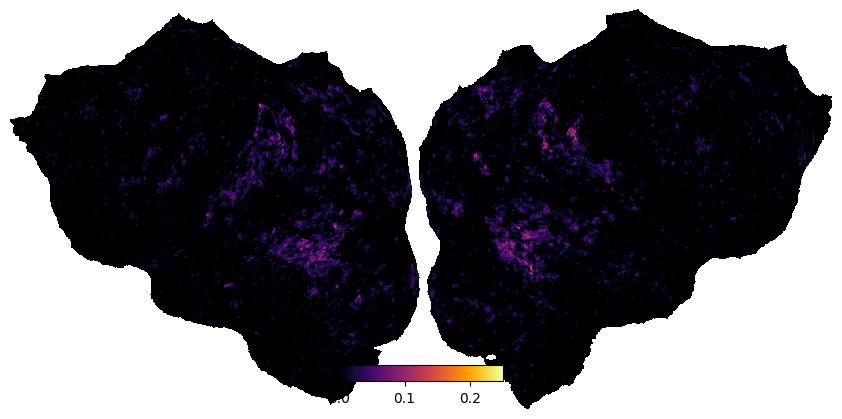

In [63]:
scores_gaze_KLR = clean_scores(scores_gaze_KLR)

subject ="KLR"

v = cortex.Volume(scores_gaze_KLR, "KLRfs", "report-attn", cmap='inferno', vmin=0, vmax=.25)
cortex.quickshow(v, height=400)
plt.show()

In [64]:
# Load gaze-corrected features for ZXI
GAZE_FEATURES_DIR = "/home/jlg/shiochiba/gaze-corrected-semantics/data/features"
feature_name = 'visual_ZXI-gaze-corrected-semantics.npz'
features = np.load(os.path.join(GAZE_FEATURES_DIR, feature_name))

if 'gaze' in feature_name:
    realfeatures_ZXI = {}
    for movie, feature in features.items():
        if 'match' in movie:
            newname = movie.replace('match', '')
            print(newname)
            realfeatures_ZXI[newname] = feature

    train_keys_gaze_ZXI = [k for k in realfeatures_ZXI.keys() if k.startswith('train')]

    X_train_gaze_ZXI = np.concatenate([realfeatures_ZXI[k][5:] for k in train_keys_gaze_ZXI], axis=0).astype('float32')

    X_test_gaze_ZXI  = realfeatures_ZXI['test2'][5:].astype('float32')

else:
    train_keys_gaze_ZXI = [k for k in features.files if k.startswith('train')]

    X_train_gaze_ZXI = np.concatenate([features[k][5:] for k in train_keys_gaze_ZXI], axis=0).astype('float32')

    X_test_gaze_ZXI = features['test2'][5:].astype('float32')

print("X_train_gaze_ZXI shape:", X_train_gaze_ZXI.shape)
print("X_test_gaze_ZXI shape:", X_test_gaze_ZXI.shape)


test2
train01
train02
train03
train04
train05
train06
train07
train08
train09
train10
X_train_gaze_ZXI shape: (1471, 270)
X_test_gaze_ZXI shape: (86, 270)


In [65]:
# Feature z-scoring
X_train_gaze_ZXI, X_test_gaze_ZXI = zscore_features(X_train_gaze_ZXI, X_test_gaze_ZXI)

In [66]:
n_samples_train_gaze_ZXI = X_train_gaze_ZXI.shape[0]
cv_gaze_ZXI = generate_leave_one_run_out(n_samples_train_gaze_ZXI, run_onsets_ZXI)
cv_gaze_ZXI = check_cv(cv_gaze_ZXI)

In [67]:
# Fit model with gaze-corrected features for ZXI
pipeline_gaze_ZXI, scores_gaze_ZXI = fit_kernel_ridge(
    X_train_gaze_ZXI, X_test_gaze_ZXI, Y_train_ZXI, Y_test_ZXI,
    cv = cv_gaze_ZXI,
    delays=[1, 2, 3, 4],
    n_targets_batch=500,
    n_alphas_batch=10,
    n_targets_batch_refit=100, 
)

print("Scores shape:", scores_gaze_ZXI.shape)

/home/jlg/shiochiba/miniconda3/envs/vem/lib/python3.10/site-packages/himalaya/kernel_ridge/_sklearn_api.py:499: UserWarning: Solving linear kernel ridge is slower than solving ridge when n_samples > n_features (here 1471 > 1080). Using himalaya.ridge.RidgeCV would be faster. Use warn=False to silence this warning.
  warnings.warn(


Scores shape: torch.Size([92811])


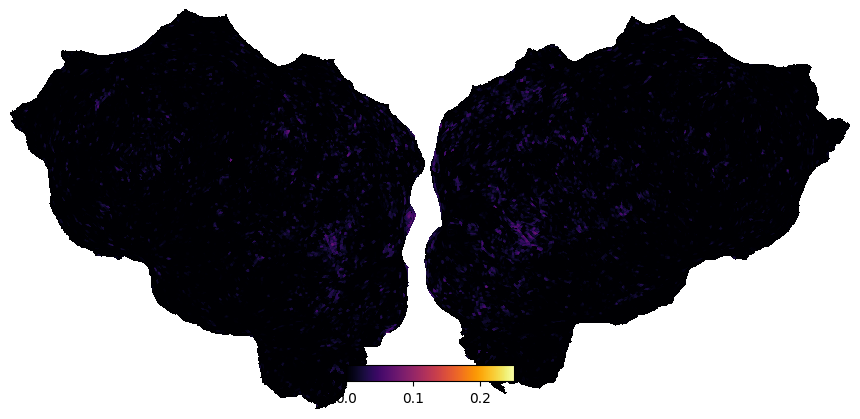

In [68]:
scores_gaze_ZXI = clean_scores(scores_gaze_ZXI)

subject ="ZXI"

v = cortex.Volume(scores_gaze_ZXI, "ZXIfs", "report-attn", cmap='inferno', vmin=0, vmax=.25)
cortex.quickshow(v, height=400)
plt.show()

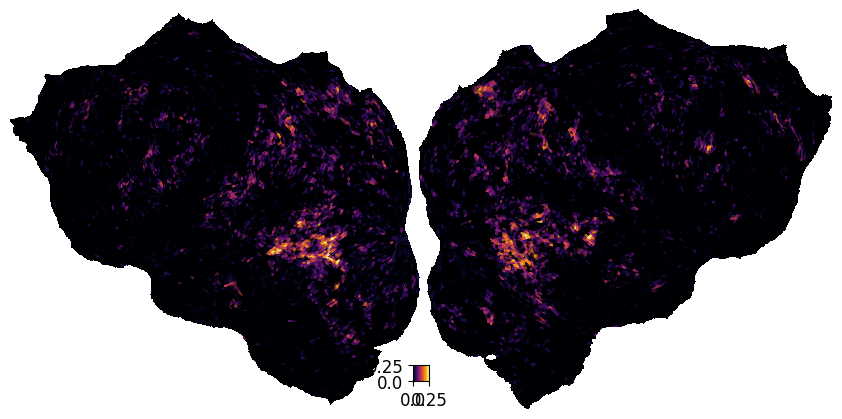

In [69]:
# Compare both models for KLR
v2d_KLR = cortex.dataset.Volume2D(
    scores_std_KLR, scores_gaze_KLR, 
    subject="KLRfs", xfmname="report-attn", 
    cmap = 'inferno', 
    vmin=0, vmax=.25, 
    vmin2=0, vmax2= 0.25
    )
cortex.quickshow(v2d_KLR, height=400)
plt.show()

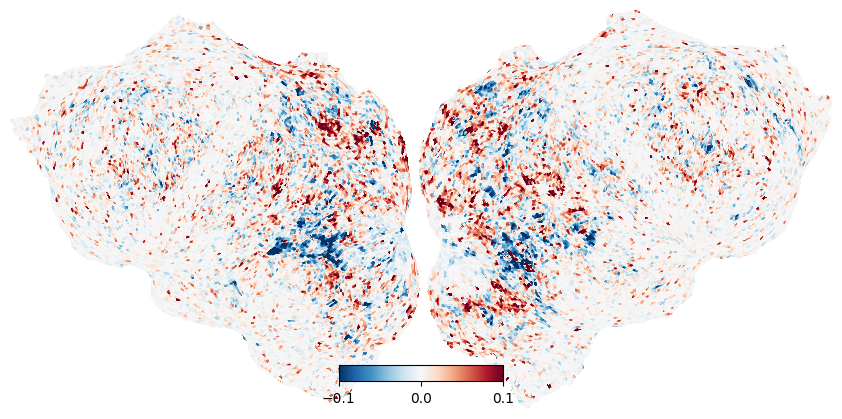

In [73]:
# KLR difference map where red = gaze corrected model predicts better, blue = standard predicts better

v_diff_KLR = cortex.Volume(
    scores_gaze_KLR - scores_std_KLR,
    subject = "KLRfs", xfmname ="report-attn",
    cmap = 'RdBu_r',
    vmin=-0.1, vmax=0.1
)
cortex.quickshow(v_diff_KLR, height=400)
plt.show()

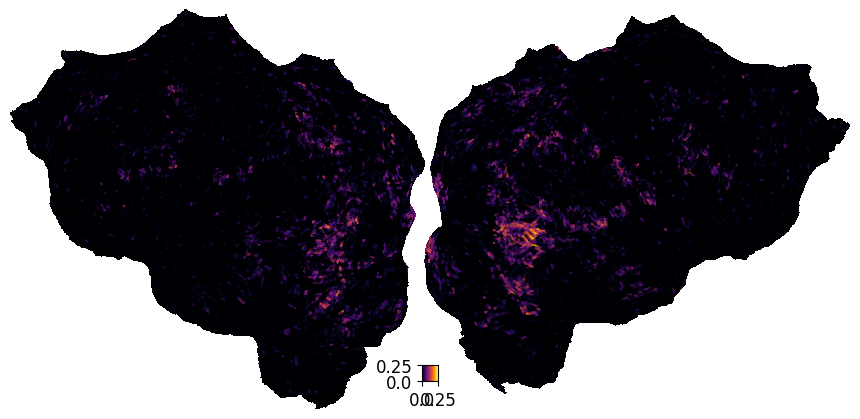

In [70]:
# Compare both models for ZXI
v2d_ZXI = cortex.dataset.Volume2D(
    scores_std_ZXI, scores_gaze_ZXI, 
    subject="ZXIfs", xfmname="report-attn", 
    cmap = 'inferno', 
    vmin=0, vmax=.25,
    vmin2=0, vmax2=.25
    )
cortex.quickshow(v2d_ZXI, height=400)
plt.show()

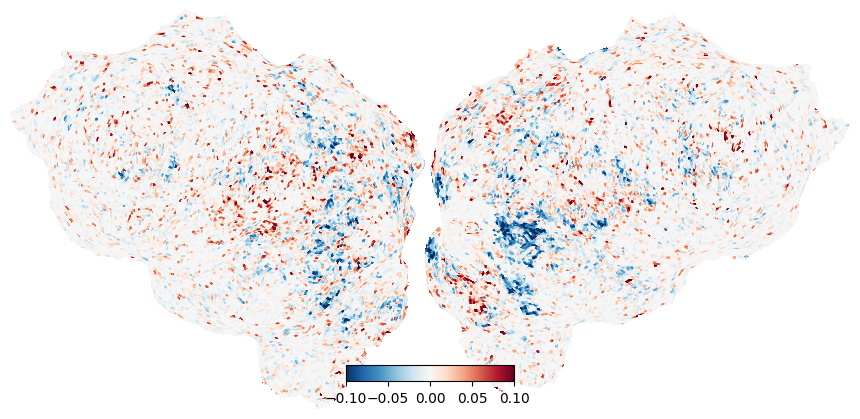

In [74]:
# ZXI difference map where red = gaze corrected model predicts better, blue = standard predicts better

v_diff_ZXI = cortex.Volume(
    scores_gaze_ZXI - scores_std_ZXI,
    subject = "ZXIfs", xfmname ="report-attn",
    cmap = 'RdBu_r',
    vmin=-0.1, vmax=0.1
)
cortex.quickshow(v_diff_ZXI, height=400)
plt.show()